# 02 — From Images to Light Curves (Photometry)

**Hack4Dev Iraq 2026 · Exoplanet Data Challenge · Track F (AI Challenge)**
Team: Mostafa & Sara

In notebook 01 we learned what the data is. Now we turn **images into numbers**: for every image we measure the brightness of many stars, and for every star we build a **light curve** (brightness vs. time).

These light curves are the input of our AI model in notebook 03.

## The idea in 4 steps

1. **Remove the camera signal** — subtract a dark frame (same as notebook 01).
2. **Find the stars** — a detector looks for small round bright spots.
3. **Align the frames** — the telescope does not track perfectly, so stars move up to ~55 pixels during a night. We must follow each star, not a fixed position.
4. **Measure brightness** — put a small circle (*aperture*) on each star, add up the light inside, and subtract the sky background measured in a ring around it.

### Why relative brightness?

Clouds, haze and the star sinking towards the horizon make **all** stars dimmer at the same time. So a single star's raw brightness is useless. We divide each star by the sum of the other stars in the same image:

```
relative brightness of star A = flux(A) / sum of flux of all other stars
```

Anything that affects the whole sky cancels out. What remains is what happened to *that star alone* — which is where a transit would appear.

**And this is exactly where false positives come from:** if clouds are patchy, or a star drifts onto a bad pixel, the division does not cancel perfectly and we get a fake dip. Our AI in notebook 03 learns to separate those from real transits.

## Step 1 — Setup

In [ ]:
# Step 1: imports and paths
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, CircularAnnulus, ApertureStats

warnings.filterwarnings("ignore")     # photutils warns when a cloudy frame has no stars; we handle that ourselves

DATA_DIR = Path("..") / "database"
OUTPUT_DIR = Path("..") / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# The clean table we built in notebook 01
frames = pd.read_csv(OUTPUT_DIR / "frames_index.csv")
calibration_files = sorted((DATA_DIR / "calibration").rglob("*.fits"))
print("frames:", len(frames), " calibration files:", len(calibration_files))

frames: 1681  calibration files: 60


## Step 2 — The building blocks

Three small functions. Read them once; we reuse them for every night.

In [ ]:
# Step 2a: the dark frame for a given night (same helper as notebook 01)
dark_dates = sorted({p.parts[-2] for p in calibration_files})

def load_dark(night):
    """Median of the dark frames taken on the same date (or the closest date)."""
    closest = min(dark_dates, key=lambda d: abs(pd.Timestamp(d) - pd.Timestamp(night)))
    paths = [p for p in calibration_files if p.parts[-2] == closest]
    return np.median([fits.getdata(p).astype(float) for p in paths], axis=0)

In [ ]:
# Step 2b: find stars in one image
def detect_stars(image, threshold_sigma=8, max_stars=400):
    """Return the (x, y) positions and brightness of the stars, brightest first.

    threshold_sigma = how far above the noise a spot must be to count as a star.
    Returns (None, None) when the sky is covered by clouds and nothing is found.
    """
    _, background, noise = sigma_clipped_stats(image, sigma=3)
    found = DAOStarFinder(fwhm=2.5, threshold=threshold_sigma * noise)(image - background)
    if found is None:
        return None, None
    found.sort("flux", reverse=True)
    positions = np.transpose((found["x_centroid"][:max_stars], found["y_centroid"][:max_stars]))
    return positions, np.array(found["flux"][:max_stars])

In [ ]:
# Step 2c: how far did the whole star field move between two images?
def find_offset(positions, reference_positions, max_shift=90):
    """Estimate the (dx, dy) shift between one frame and the reference frame.

    Idea: compute the difference between every star here and every star in the reference.
    The true shift is the value that appears most often (real stars all move together;
    wrong pairs give random values). Returns (shift, how many pairs agreed).
    """
    diffs = (positions[:, None, :] - reference_positions[None, :, :]).reshape(-1, 2)
    diffs = diffs[(np.abs(diffs[:, 0]) < max_shift) & (np.abs(diffs[:, 1]) < max_shift)]
    if len(diffs) < 5:
        return None, 0
    counts = {}
    for dx, dy in np.round(diffs).astype(int):
        counts[(dx, dy)] = counts.get((dx, dy), 0) + 1
    (dx, dy), votes = max(counts.items(), key=lambda kv: kv[1])
    precise = diffs[(np.abs(diffs[:, 0] - dx) < 2) & (np.abs(diffs[:, 1] - dy) < 2)]
    return precise.mean(axis=0), votes

## Step 3 — Watch the drift on one night

Before processing everything, let us see the problem with our own eyes on one clear night.

stars in the reference frame: 400


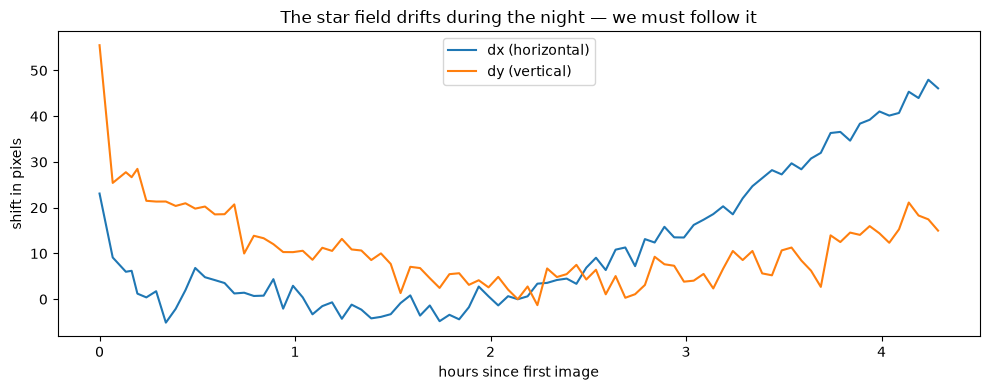

total drift: 53 px horizontally, 57 px vertically


In [ ]:
# Step 3: measure how much the star field moves during one night
night_frames = frames[(frames.target == "CoRoT-2") & (frames.night == "2026-08-09")].sort_values("mjd").reset_index(drop=True)
dark = load_dark("2026-08-09")

reference_image = fits.getdata(DATA_DIR / night_frames.path[len(night_frames) // 2]).astype(float) - dark
reference_positions, reference_flux = detect_stars(reference_image)
print("stars in the reference frame:", len(reference_positions))

shifts = []
for path in night_frames.path:
    image = fits.getdata(DATA_DIR / path).astype(float) - dark
    positions, _ = detect_stars(image, max_stars=100)
    shift, votes = (None, 0) if positions is None else find_offset(positions, reference_positions)
    shifts.append(shift if shift is not None else (np.nan, np.nan))
shifts = np.array(shifts)

hours = (night_frames.mjd - night_frames.mjd.min()) * 24
plt.figure(figsize=(10, 4))
plt.plot(hours, shifts[:, 0], label="dx (horizontal)")
plt.plot(hours, shifts[:, 1], label="dy (vertical)")
plt.xlabel("hours since first image")
plt.ylabel("shift in pixels")
plt.title("The star field drifts during the night — we must follow it")
plt.legend()
plt.tight_layout()
plt.show()

print(f"total drift: {np.nanmax(shifts[:,0])-np.nanmin(shifts[:,0]):.0f} px horizontally, "
      f"{np.nanmax(shifts[:,1])-np.nanmin(shifts[:,1]):.0f} px vertically")

## Step 4 — Measure one whole night

Now the full recipe for one night. Important details, each one a decision we must be able to defend:

- **Reference frame**: we do *not* use the middle image (on a cloudy night it may show no stars). We test 12 images spread over the night and keep the one with the most stars.
- **Edge margin**: stars close to the edge leave the image when the field drifts, so we only keep stars further from the edge than the largest drift of the night.
- **Brightest 40 stars**: faint stars are mostly noise and would spoil the comparison sum.
- **A star is kept** if it was measured in at least 90% of the *aligned* frames.
- **A frame is kept** if it aligned and at least 80% of the kept stars were measured in it.

In [ ]:
# Step 4: full photometry for one night
def measure_night(target, night, aperture_radius=4.0, n_stars=40, verbose=True):
    """Measure the brightness of the brightest stars in every image of one night."""
    g = frames[(frames.target == target) & (frames.night == night)].sort_values("mjd").reset_index(drop=True)
    dark = load_dark(night)

    # 1) choose the best reference frame: the one with the most stars
    best_count, best = -1, None
    for i in np.linspace(0, len(g) - 1, 12).astype(int):
        image = fits.getdata(DATA_DIR / g.path[i]).astype(float) - dark
        positions, flux = detect_stars(image)
        count = 0 if positions is None else len(positions)
        if count > best_count:
            best_count, best = count, (positions, flux)
    ref_positions, ref_flux = best
    if ref_positions is None or best_count < 15:
        if verbose: print(f"{target} {night}: unusable, best frame has {best_count} stars")
        return None

    # 2) align every frame and keep the images in memory
    shifts, images = [], []
    for path in g.path:
        image = fits.getdata(DATA_DIR / path).astype(float) - dark
        positions, _ = detect_stars(image, max_stars=100)
        shift, votes = (None, 0) if positions is None else find_offset(positions, ref_positions)
        shifts.append(shift if (shift is not None and votes >= 5) else None)
        images.append(image)
    aligned = np.array([s is not None for s in shifts])
    if aligned.sum() < 20:
        if verbose: print(f"{target} {night}: only {aligned.sum()} frames could be aligned")
        return None

    # 3) keep stars that stay inside the image all night, then the brightest ones
    margin = np.abs(np.array([s for s in shifts if s is not None])).max() + 16
    inside = ((ref_positions[:, 0] > margin) & (ref_positions[:, 0] < 650 - margin) &
              (ref_positions[:, 1] > margin) & (ref_positions[:, 1] < 500 - margin))
    positions, flux = ref_positions[inside], ref_flux[inside]
    brightest = np.argsort(-flux)[:n_stars]
    positions = positions[brightest]

    # 4) aperture photometry: light inside a circle, minus the sky measured in a ring around it
    net = np.full((len(g), len(positions)), np.nan)
    for i in range(len(g)):
        if shifts[i] is None:
            continue
        here = positions + shifts[i]
        aperture = CircularAperture(here, r=aperture_radius)
        ring = CircularAnnulus(here, r_in=aperture_radius + 4, r_out=aperture_radius + 9)
        sky = ApertureStats(images[i], ring).median
        net[i] = ApertureStats(images[i], aperture).sum - sky * aperture.area

    # 5) quality rules
    measured = np.isfinite(net) & (net > 0)
    star_ok = measured[aligned].mean(axis=0) >= 0.90     # measured in 90% of aligned frames
    if star_ok.sum() < 5:
        if verbose: print(f"{target} {night}: only {star_ok.sum()} usable stars")
        return None
    frame_ok = aligned & (measured[:, star_ok].mean(axis=1) >= 0.80)
    net = np.where(measured, net, np.nan)

    if verbose:
        print(f"{target} {night}: {aligned.sum()}/{len(g)} frames aligned, "
              f"{star_ok.sum()} stars kept, {frame_ok.sum()} frames kept")
    return {"target": target, "night": night, "table": g, "positions": positions,
            "net": net, "star_ok": star_ok, "frame_ok": frame_ok,
            "shifts": np.array([s if s is not None else (np.nan, np.nan) for s in shifts])}

result = measure_night("CoRoT-2", "2026-08-09")

CoRoT-2 2026-08-09: 87/87 frames aligned, 40 stars kept, 87 frames kept


## Step 5 — From brightness to relative brightness

For each star we divide by the sum of the **other** kept stars, then divide by the median so a normal night sits at 1.0.
A transit would appear as a dip below 1.0.

In [ ]:
# Step 5: turn raw brightness into relative brightness
def relative_curves(result):
    """Return a (frames x stars) array of relative brightness, normalised to 1.0."""
    net, star_ok, frame_ok = result["net"], result["star_ok"], result["frame_ok"]
    kept = np.where(star_ok)[0]
    curves = np.full((net.shape[0], len(kept)), np.nan)
    for k, j in enumerate(kept):
        others = np.nansum(net[:, [i for i in kept if i != j]], axis=1)
        rel = net[:, j] / others
        usable = frame_ok & np.isfinite(rel)
        if usable.sum() < 20:
            continue
        curves[:, k] = rel / np.median(rel[usable])
    return curves, kept

curves, kept_stars = relative_curves(result)
scatter = np.nanstd(curves[result["frame_ok"]], axis=0) * 100
print(f"{curves.shape[1]} light curves")
print(f"scatter per star: median {np.nanmedian(scatter):.2f}%, best {np.nanmin(scatter):.2f}%")
print("\nThe best stars reach about 1%. A transit of these planets is 1.6% to 2.75% deep,")
print("so we are close to the limit — this is exactly why we need a careful detector, not a naive one.")

40 light curves
scatter per star: median 1.68%, best 0.90%

The best stars reach about 1%. A transit of these planets is 1.6% to 2.75% deep,
so we are close to the limit — this is exactly why we need a careful detector, not a naive one.


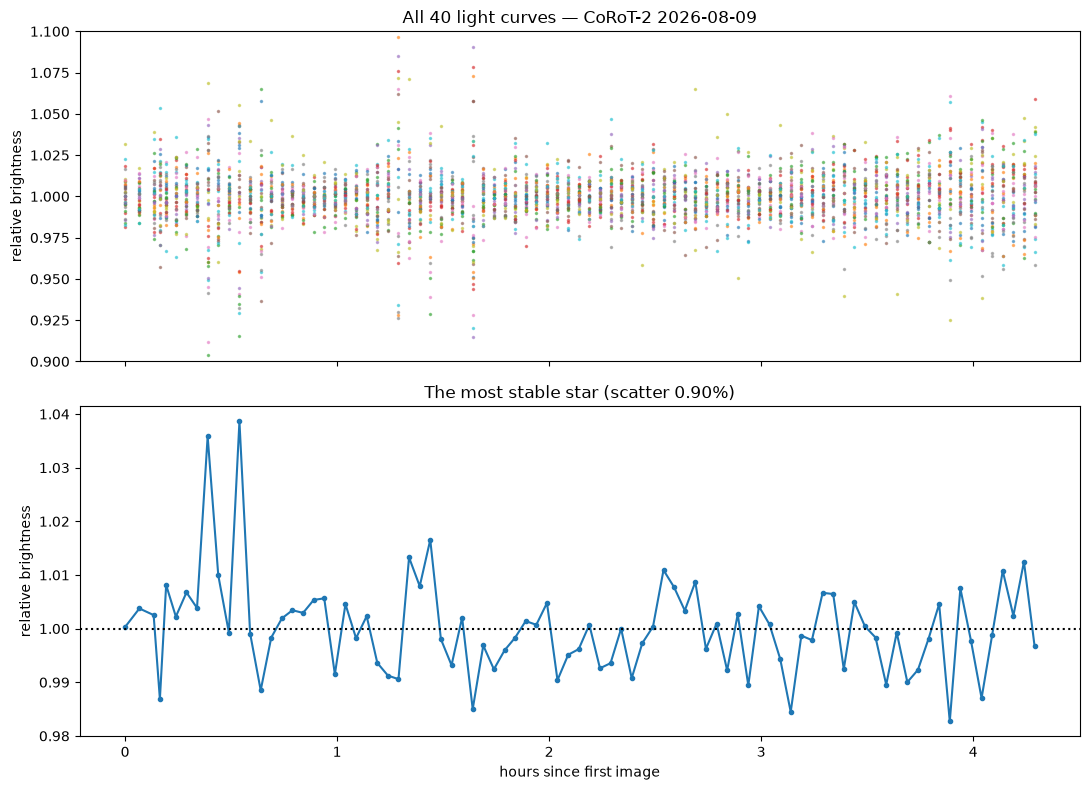

In [ ]:
# Step 5b: plot the light curves of this night
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
hours = (result["table"].mjd - result["table"].mjd.min()) * 24
ok = result["frame_ok"]

for k in range(curves.shape[1]):
    axes[0].plot(hours[ok], curves[ok, k], ".", ms=3, alpha=0.5)
axes[0].set_ylabel("relative brightness")
axes[0].set_title(f"All {curves.shape[1]} light curves — {result['target']} {result['night']}")
axes[0].set_ylim(0.9, 1.1)

best = int(np.nanargmin(scatter))
axes[1].plot(hours[ok], curves[ok, best], ".-", color="tab:blue")
axes[1].axhline(1.0, ls=":", color="k")
axes[1].set_xlabel("hours since first image")
axes[1].set_ylabel("relative brightness")
axes[1].set_title(f"The most stable star (scatter {scatter[best]:.2f}%)")
plt.tight_layout()
plt.show()

## Step 6 — Run every night and save the result

This processes all 22 nights (about 1–2 minutes) and saves one long table where each row is
**one star, in one image, on one night**. Notebook 03 reads this file.

We also keep the observing conditions of each image (altitude, weather, sky brightness, drift),
because those are the features the AI will use to recognise false positives.

In [ ]:
# Step 6: process all nights
all_rows = []
quality = []

for (target, night), _ in frames.groupby(["target", "night"]):
    result = measure_night(target, night, verbose=False)
    if result is None:
        quality.append({"target": target, "night": night, "stars": 0, "frames_kept": 0, "median_scatter_%": np.nan})
        print(f"skipped {target} {night} (too cloudy)")
        continue

    curves, kept = relative_curves(result)
    scatter = np.nanstd(curves[result["frame_ok"]], axis=0) * 100
    g = result["table"]

    for k in range(curves.shape[1]):
        for i in range(len(g)):
            if not result["frame_ok"][i] or not np.isfinite(curves[i, k]):
                continue
            all_rows.append({
                "target": target, "night": night, "star_id": k,
                # position in the reference frame: the planet host is the star near the centre
                "star_x": result["positions"][kept[k], 0], "star_y": result["positions"][kept[k], 1],
                "mjd": g.mjd[i], "time_ut": g.time_ut[i],
                "rel_flux": curves[i, k], "raw_flux": result["net"][i, kept[k]],
                "altitude_deg": g.altitude_deg[i], "weather": g.weather[i],
                "sky_median": g.sky_median[i],
                "dx": result["shifts"][i, 0], "dy": result["shifts"][i, 1],
            })
    quality.append({"target": target, "night": night, "stars": curves.shape[1],
                    "frames_kept": int(result["frame_ok"].sum()),
                    "median_scatter_%": float(np.nanmedian(scatter))})

light_curves = pd.DataFrame(all_rows)
quality = pd.DataFrame(quality)
light_curves.to_csv(OUTPUT_DIR / "light_curves.csv", index=False)
quality.to_csv(OUTPUT_DIR / "photometry_quality.csv", index=False)

print(f"\nsaved {len(light_curves)} measurements")
print(f"usable nights: {(quality.stars > 0).sum()} of {len(quality)}")
quality.round(2)

skipped CoRoT-2 2026-08-30 (too cloudy)
skipped Qatar-1 2026-08-28 (too cloudy)
skipped TRES-1 2026-08-06 (too cloudy)

saved 46231 measurements
usable nights: 19 of 22


,target,night,stars,frames_kept,median_scatter_%
0,CoRoT-2,2026-08-09,40,87,1.68
1,CoRoT-2,2026-08-16,40,86,1.33
2,CoRoT-2,2026-08-23,40,28,16.03
3,CoRoT-2,2026-08-30,0,0,NaN
4,HATP-10,2026-09-05,40,84,1.71
5,Qatar-1,2026-08-18,40,71,1.47
6,Qatar-1,2026-08-21,40,74,1.42
7,Qatar-1,2026-08-28,0,0,NaN
8,TRES-1,2026-08-06,0,0,NaN
9,TRES-3,2026-08-10,40,51,7.55


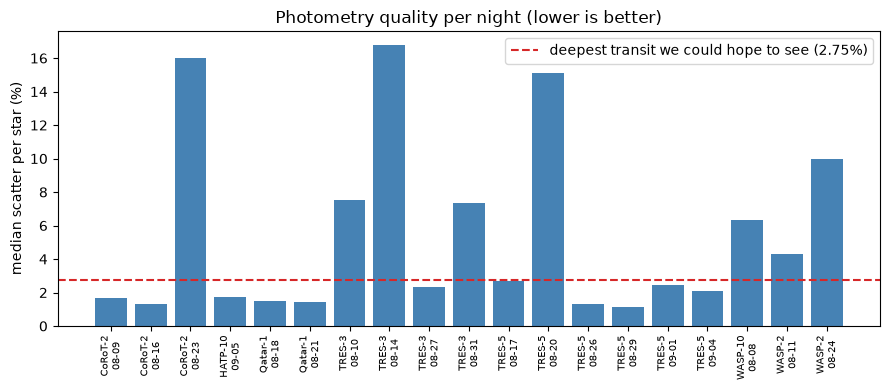

In [ ]:
# Step 6b: how good is our photometry overall?
plt.figure(figsize=(9, 4))
good = quality[quality.stars > 0]
plt.bar(range(len(good)), good["median_scatter_%"], color="steelblue")
plt.xticks(range(len(good)), [f"{t}\n{n[5:]}" for t, n in zip(good.target, good.night)], fontsize=7, rotation=90)
plt.axhline(2.75, color="tab:red", ls="--", label="deepest transit we could hope to see (2.75%)")
plt.ylabel("median scatter per star (%)")
plt.title("Photometry quality per night (lower is better)")
plt.legend()
plt.tight_layout()
plt.show()

## Decision log (add to the README)

| # | Decision | Reason |
|---|---|---|
| 8 | Reference frame = the image with the most stars, not the middle image | On cloudy nights the middle image can show no stars at all |
| 9 | Follow the stars frame by frame (alignment) instead of fixed positions | The field drifts up to ~55 pixels per night; fixed apertures measure empty sky |
| 10 | Only keep stars further from the edge than the night's largest drift | Otherwise stars leave the image and produce fake dips |
| 11 | Use the 40 brightest stars, comparison = sum of the others | Faint stars are dominated by noise and would spoil the comparison |
| 12 | Drop frames that cannot be aligned, and stars missing in >10% of aligned frames | Missing measurements create fake brightness jumps |

## Try it yourself

1. Change `aperture_radius` in `measure_night` to 3 and then to 6, and look at the scatter. Which radius is best? Why do you think a very large circle is worse?
2. Run `measure_night("TRES-3", "2026-08-31")` and compare its scatter with the CoRoT-2 night. What is different about that night in notebook 01's tables?
3. In Step 5b, is the "most stable star" really flat, or does it drift slowly? What in the observing conditions could cause a slow drift?

**Next:** `03_ai_model.ipynb` — inject artificial transits into these light curves, build features, train a model, and compare it against a simple threshold with a confusion matrix.